# MelodyMatch-V2 — Confusion Matrix Analysis

This notebook analyzes class-level predictions for the original CNN and the Decoupled Training model.

The analysis focuses on:

- Confusion matrices
- Normalized confusion matrices
- Per-class precision, recall, and F1
- Changes in class-level F1 between the two models
- Major class-level prediction changes

No model training is performed in this notebook.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

In [3]:
cnn_cm = pd.read_csv(
    METRICS_DIR / "cnn_baseline_test_confusion_matrix.csv",
    index_col=0,
)

decoupled_cm = pd.read_csv(
    METRICS_DIR / "cnn_decoupled_test_confusion_matrix.csv",
    index_col=0,
)

print("CNN confusion matrix:")
display(cnn_cm)

print("Decoupled Training confusion matrix:")
display(decoupled_cm)

CNN confusion matrix:


,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
Blues,3,0,0,0,0,2,1,0,0,0,0,0,0,1,0,1
Classical,1,53,0,0,0,4,0,0,2,0,1,0,1,0,0,0
Country,1,0,8,0,0,0,5,0,0,1,0,0,3,0,0,0
Easy Listening,0,2,0,0,0,0,0,0,4,0,0,0,0,0,0,0
Electronic,0,2,0,0,432,51,7,23,46,8,8,0,20,8,26,1
Experimental,1,9,1,0,18,94,10,2,45,5,7,0,13,9,4,7
Folk,2,2,2,0,0,24,56,0,15,6,4,3,15,21,0,2
Hip-Hop,0,0,0,0,28,8,0,166,1,5,1,0,3,0,4,4
Instrumental,0,3,2,0,6,19,52,1,64,0,1,0,18,5,1,2
International,2,2,14,0,5,0,17,5,2,38,6,0,7,1,2,1


Decoupled Training confusion matrix:


,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
Blues,5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
Classical,1,54,0,0,0,1,1,0,1,0,4,0,0,0,0,0
Country,0,0,9,0,0,0,7,0,0,1,0,0,0,1,0,0
Easy Listening,0,4,0,0,0,0,0,0,2,0,0,0,0,0,0,0
Electronic,1,4,0,20,454,51,2,12,33,4,8,0,19,6,16,2
Experimental,4,5,1,5,15,94,15,2,33,2,7,0,12,20,1,9
Folk,6,2,3,0,1,20,55,0,7,3,3,3,26,19,1,3
Hip-Hop,1,0,0,16,16,5,0,160,2,0,2,0,1,0,8,9
Instrumental,3,6,0,4,3,14,41,1,63,3,5,0,17,13,0,1
International,4,4,13,1,9,0,9,3,1,38,10,0,2,1,5,2


In [4]:
print("CNN classes:")
print(cnn_cm.index.tolist())

print("\nDecoupled classes:")
print(decoupled_cm.index.tolist())

print("\nColumns match:", cnn_cm.columns.tolist() == decoupled_cm.columns.tolist())

CNN classes:
['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

Decoupled classes:
['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

Columns match: True


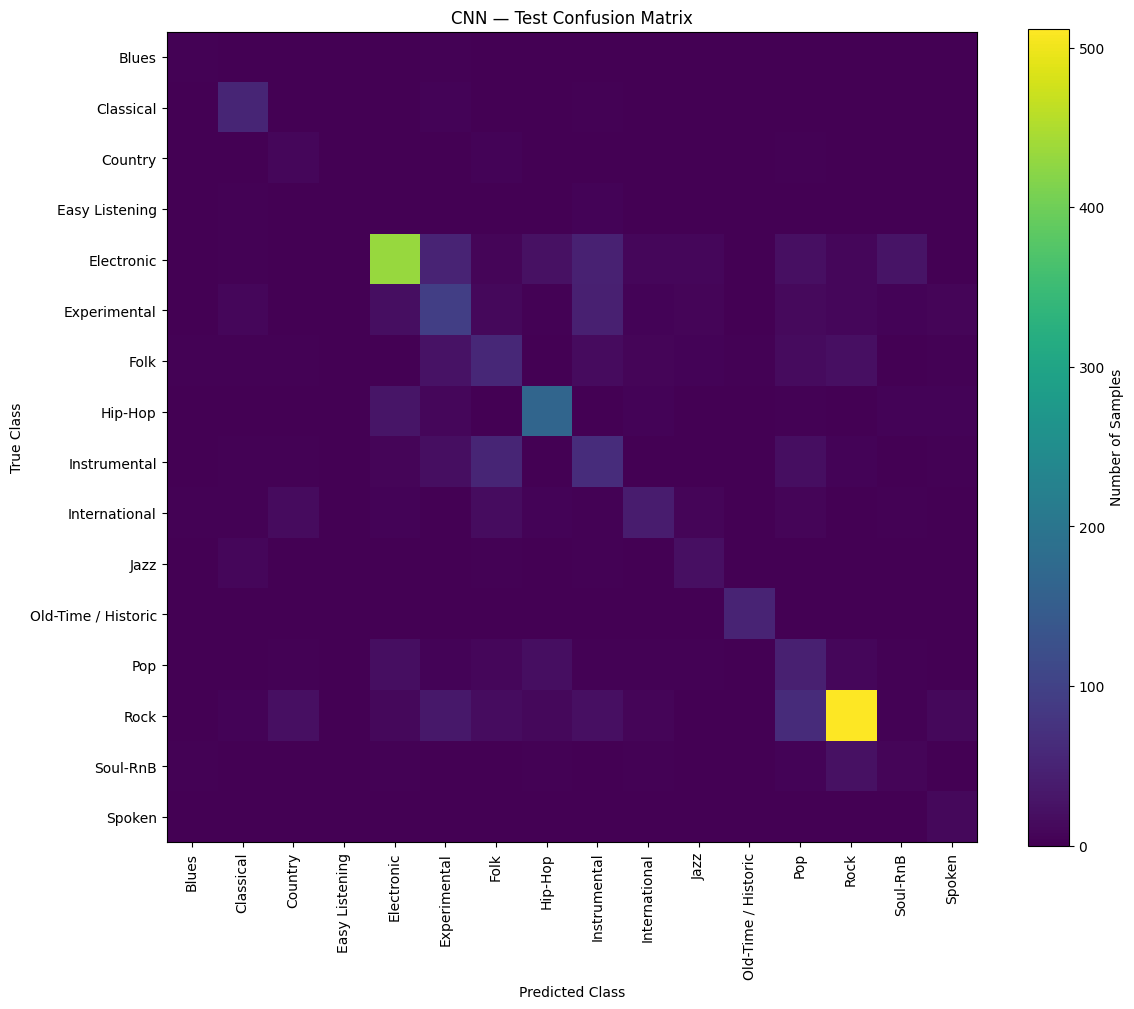

In [5]:
plt.figure(figsize=(12, 10))

plt.imshow(cnn_cm.values)

plt.title("CNN — Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(cnn_cm.columns)),
    cnn_cm.columns,
    rotation=90,
)

plt.yticks(
    range(len(cnn_cm.index)),
    cnn_cm.index,
)

plt.colorbar(label="Number of Samples")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cnn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

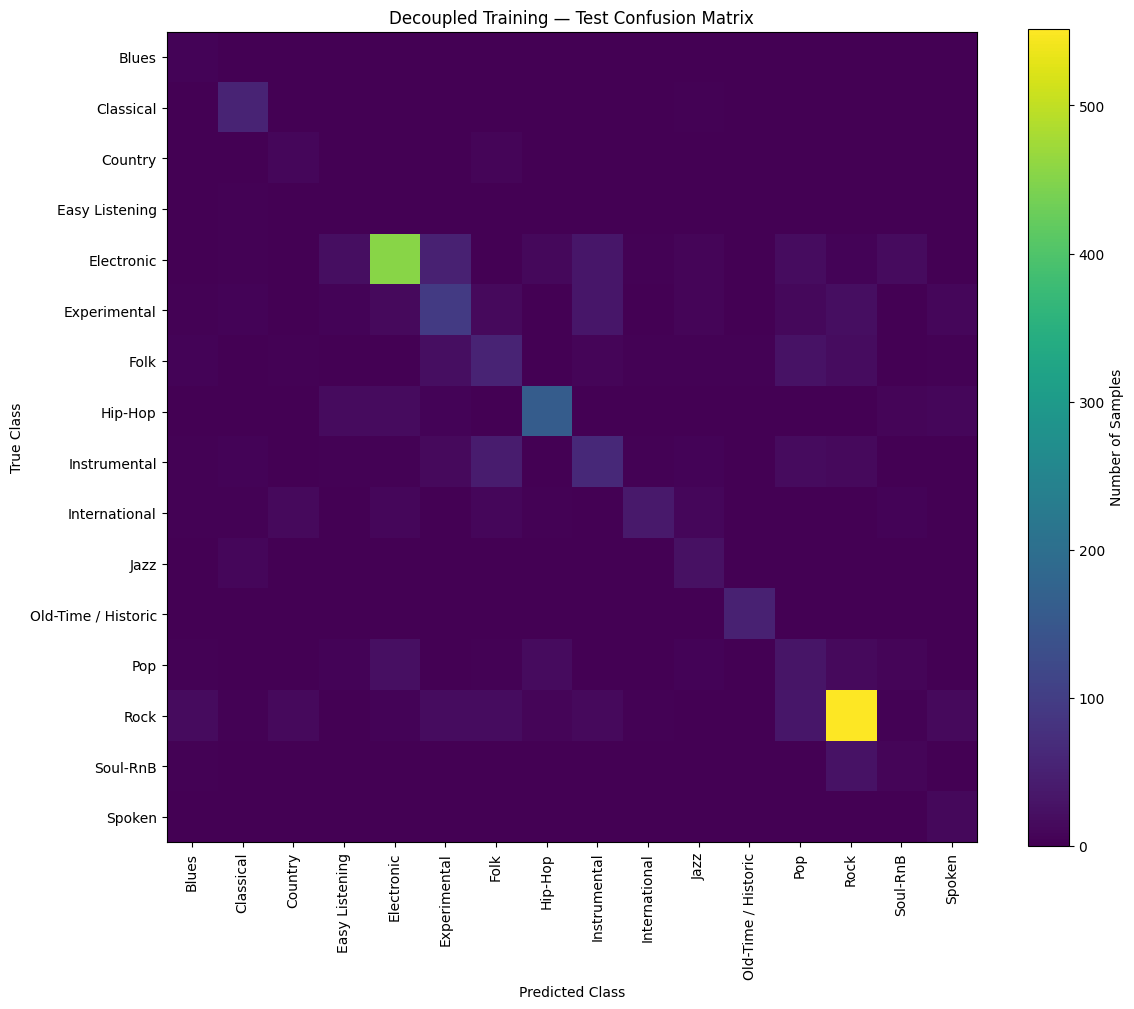

In [6]:
plt.figure(figsize=(12, 10))

plt.imshow(decoupled_cm.values)

plt.title("Decoupled Training — Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(decoupled_cm.columns)),
    decoupled_cm.columns,
    rotation=90,
)

plt.yticks(
    range(len(decoupled_cm.index)),
    decoupled_cm.index,
)

plt.colorbar(label="Number of Samples")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "decoupled_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
cnn_cm_normalized = cnn_cm.div(
    cnn_cm.sum(axis=1),
    axis=0,
).fillna(0)

cnn_cm_normalized.round(3)

,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
Blues,0.375,0.000,0.000,0.000,0.000,0.250,0.125,0.000,0.000,0.000,0.000,0.00,0.000,0.125,0.000,0.125
Classical,0.016,0.855,0.000,0.000,0.000,0.065,0.000,0.000,0.032,0.000,0.016,0.00,0.016,0.000,0.000,0.000
Country,0.056,0.000,0.444,0.000,0.000,0.000,0.278,0.000,0.000,0.056,0.000,0.00,0.167,0.000,0.000,0.000
Easy Listening,0.000,0.333,0.000,0.000,0.000,0.000,0.000,0.000,0.667,0.000,0.000,0.00,0.000,0.000,0.000,0.000
Electronic,0.000,0.003,0.000,0.000,0.684,0.081,0.011,0.036,0.073,0.013,0.013,0.00,0.032,0.013,0.041,0.002
Experimental,0.004,0.040,0.004,0.000,0.080,0.418,0.044,0.009,0.200,0.022,0.031,0.00,0.058,0.040,0.018,0.031
Folk,0.013,0.013,0.013,0.000,0.000,0.158,0.368,0.000,0.099,0.039,0.026,0.02,0.099,0.138,0.000,0.013
Hip-Hop,0.000,0.000,0.000,0.000,0.127,0.036,0.000,0.755,0.005,0.023,0.005,0.00,0.014,0.000,0.018,0.018
Instrumental,0.000,0.017,0.011,0.000,0.034,0.109,0.299,0.006,0.368,0.000,0.006,0.00,0.103,0.029,0.006,0.011
International,0.020,0.020,0.137,0.000,0.049,0.000,0.167,0.049,0.020,0.373,0.059,0.00,0.069,0.010,0.020,0.010


In [8]:
decoupled_cm_normalized = decoupled_cm.div(
    decoupled_cm.sum(axis=1),
    axis=0,
).fillna(0)

decoupled_cm_normalized.round(3)

,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
Blues,0.625,0.000,0.000,0.000,0.000,0.125,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.250
Classical,0.016,0.871,0.000,0.000,0.000,0.016,0.016,0.000,0.016,0.000,0.065,0.00,0.000,0.000,0.000,0.000
Country,0.000,0.000,0.500,0.000,0.000,0.000,0.389,0.000,0.000,0.056,0.000,0.00,0.000,0.056,0.000,0.000
Easy Listening,0.000,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.333,0.000,0.000,0.00,0.000,0.000,0.000,0.000
Electronic,0.002,0.006,0.000,0.032,0.718,0.081,0.003,0.019,0.052,0.006,0.013,0.00,0.030,0.009,0.025,0.003
Experimental,0.018,0.022,0.004,0.022,0.067,0.418,0.067,0.009,0.147,0.009,0.031,0.00,0.053,0.089,0.004,0.040
Folk,0.039,0.013,0.020,0.000,0.007,0.132,0.362,0.000,0.046,0.020,0.020,0.02,0.171,0.125,0.007,0.020
Hip-Hop,0.005,0.000,0.000,0.073,0.073,0.023,0.000,0.727,0.009,0.000,0.009,0.00,0.005,0.000,0.036,0.041
Instrumental,0.017,0.034,0.000,0.023,0.017,0.080,0.236,0.006,0.362,0.017,0.029,0.00,0.098,0.075,0.000,0.006
International,0.039,0.039,0.127,0.010,0.088,0.000,0.088,0.029,0.010,0.373,0.098,0.00,0.020,0.010,0.049,0.020


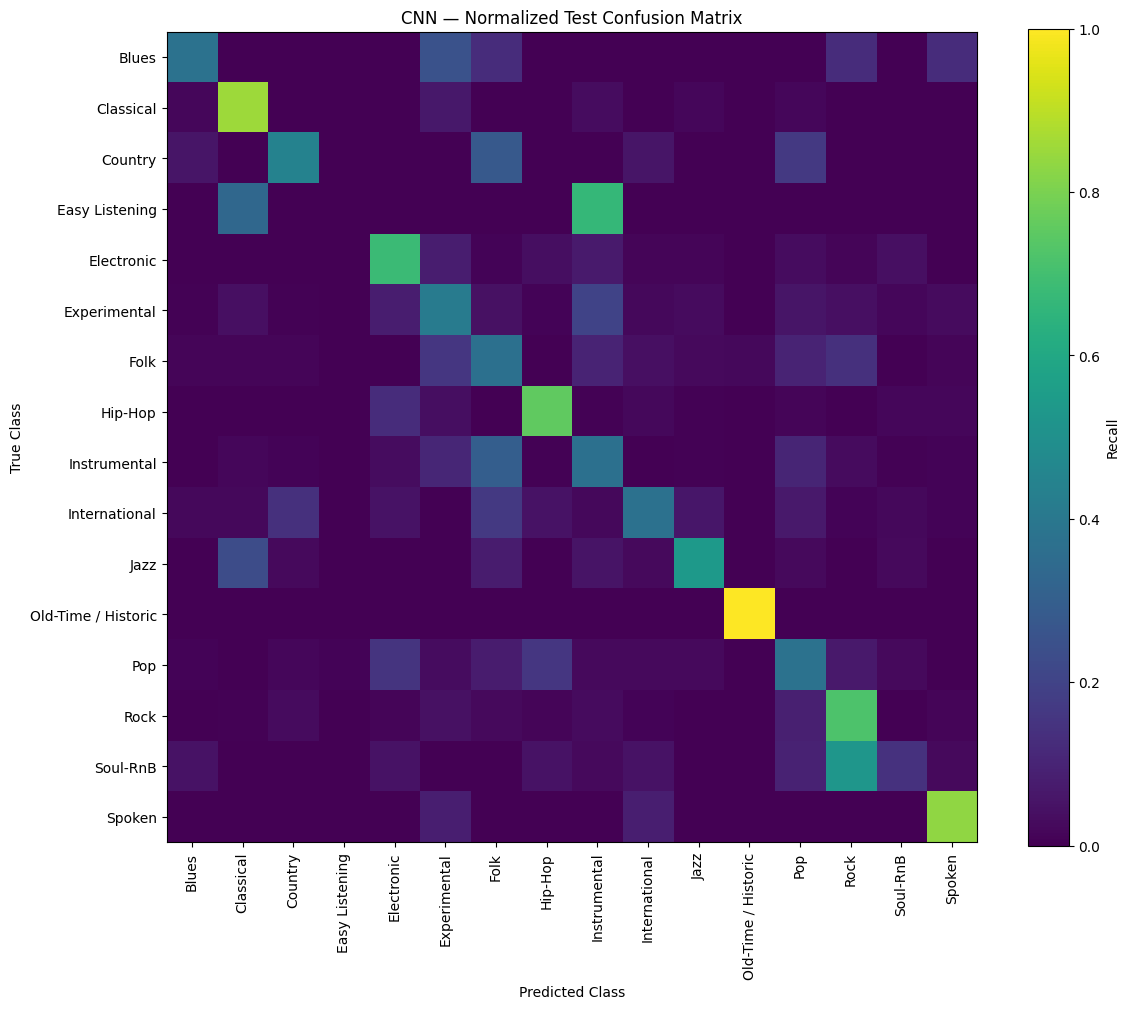

In [9]:
plt.figure(figsize=(12, 10))

plt.imshow(cnn_cm_normalized.values)

plt.title("CNN — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(cnn_cm_normalized.columns)),
    cnn_cm_normalized.columns,
    rotation=90,
)

plt.yticks(
    range(len(cnn_cm_normalized.index)),
    cnn_cm_normalized.index,
)

plt.colorbar(label="Recall")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cnn_normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

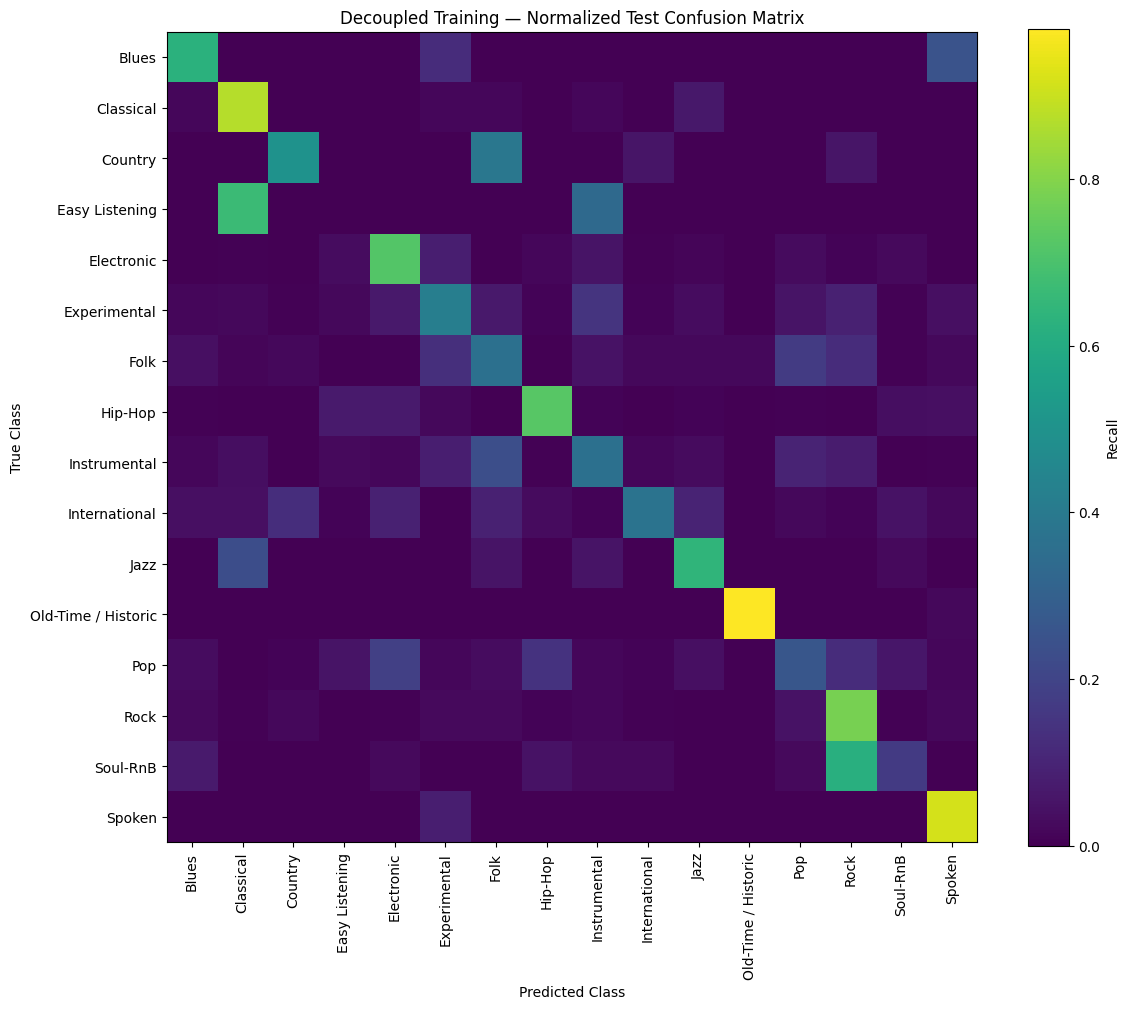

In [10]:
plt.figure(figsize=(12, 10))

plt.imshow(decoupled_cm_normalized.values)

plt.title("Decoupled Training — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(decoupled_cm_normalized.columns)),
    decoupled_cm_normalized.columns,
    rotation=90,
)

plt.yticks(
    range(len(decoupled_cm_normalized.index)),
    decoupled_cm_normalized.index,
)

plt.colorbar(label="Recall")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "decoupled_normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
cnn_report = pd.read_csv(
    METRICS_DIR / "cnn_baseline_test_classification_report.csv",
    index_col=0,
)

decoupled_report = pd.read_csv(
    METRICS_DIR / "cnn_decoupled_test_classification_report.csv",
    index_col=0,
)

print("CNN classification report:")
display(cnn_report)

print("Decoupled Training classification report:")
display(decoupled_report)

CNN classification report:


,precision,recall,f1-score,support
Blues,0.214286,0.375000,0.272727,8.000000
Classical,0.616279,0.854839,0.716216,62.000000
Country,0.156863,0.444444,0.231884,18.000000
Easy Listening,0.000000,0.000000,0.000000,6.000000
Electronic,0.832370,0.683544,0.750652,632.000000
Experimental,0.393305,0.417778,0.405172,225.000000
Folk,0.316384,0.368421,0.340426,152.000000
Hip-Hop,0.728070,0.754545,0.741071,220.000000
Instrumental,0.312195,0.367816,0.337731,174.000000
International,0.493506,0.372549,0.424581,102.000000


Decoupled Training classification report:


,precision,recall,f1-score,support
Blues,0.102041,0.625000,0.175439,8.000000
Classical,0.586957,0.870968,0.701299,62.000000
Country,0.214286,0.500000,0.300000,18.000000
Easy Listening,0.000000,0.000000,0.000000,6.000000
Electronic,0.863118,0.718354,0.784111,632.000000
Experimental,0.451923,0.417778,0.434180,225.000000
Folk,0.357143,0.361842,0.359477,152.000000
Hip-Hop,0.780488,0.727273,0.752941,220.000000
Instrumental,0.393750,0.362069,0.377246,174.000000
International,0.678571,0.372549,0.481013,102.000000


In [12]:
class_names = cnn_cm.index.tolist()

class_comparison = pd.DataFrame({
    "CNN Precision": cnn_report.loc[class_names, "precision"],
    "CNN Recall": cnn_report.loc[class_names, "recall"],
    "CNN F1": cnn_report.loc[class_names, "f1-score"],
    "Decoupled Precision": decoupled_report.loc[class_names, "precision"],
    "Decoupled Recall": decoupled_report.loc[class_names, "recall"],
    "Decoupled F1": decoupled_report.loc[class_names, "f1-score"],
})

class_comparison.round(3)

,CNN Precision,CNN Recall,CNN F1,Decoupled Precision,Decoupled Recall,Decoupled F1
Blues,0.214,0.375,0.273,0.102,0.625,0.175
Classical,0.616,0.855,0.716,0.587,0.871,0.701
Country,0.157,0.444,0.232,0.214,0.500,0.300
Easy Listening,0.000,0.000,0.000,0.000,0.000,0.000
Electronic,0.832,0.684,0.751,0.863,0.718,0.784
Experimental,0.393,0.418,0.405,0.452,0.418,0.434
Folk,0.316,0.368,0.340,0.357,0.362,0.359
Hip-Hop,0.728,0.755,0.741,0.780,0.727,0.753
Instrumental,0.312,0.368,0.338,0.394,0.362,0.377
International,0.494,0.373,0.425,0.679,0.373,0.481


In [13]:
class_comparison["F1 Change"] = (
    class_comparison["Decoupled F1"]
    - class_comparison["CNN F1"]
)

class_comparison["F1 Change (pp)"] = (
    class_comparison["F1 Change"] * 100
)

class_comparison.round(3)

,CNN Precision,CNN Recall,CNN F1,Decoupled Precision,Decoupled Recall,Decoupled F1,F1 Change,F1 Change (pp)
Blues,0.214,0.375,0.273,0.102,0.625,0.175,-0.097,-9.729
Classical,0.616,0.855,0.716,0.587,0.871,0.701,-0.015,-1.492
Country,0.157,0.444,0.232,0.214,0.500,0.300,0.068,6.812
Easy Listening,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Electronic,0.832,0.684,0.751,0.863,0.718,0.784,0.033,3.346
Experimental,0.393,0.418,0.405,0.452,0.418,0.434,0.029,2.901
Folk,0.316,0.368,0.340,0.357,0.362,0.359,0.019,1.905
Hip-Hop,0.728,0.755,0.741,0.780,0.727,0.753,0.012,1.187
Instrumental,0.312,0.368,0.338,0.394,0.362,0.377,0.040,3.951
International,0.494,0.373,0.425,0.679,0.373,0.481,0.056,5.643


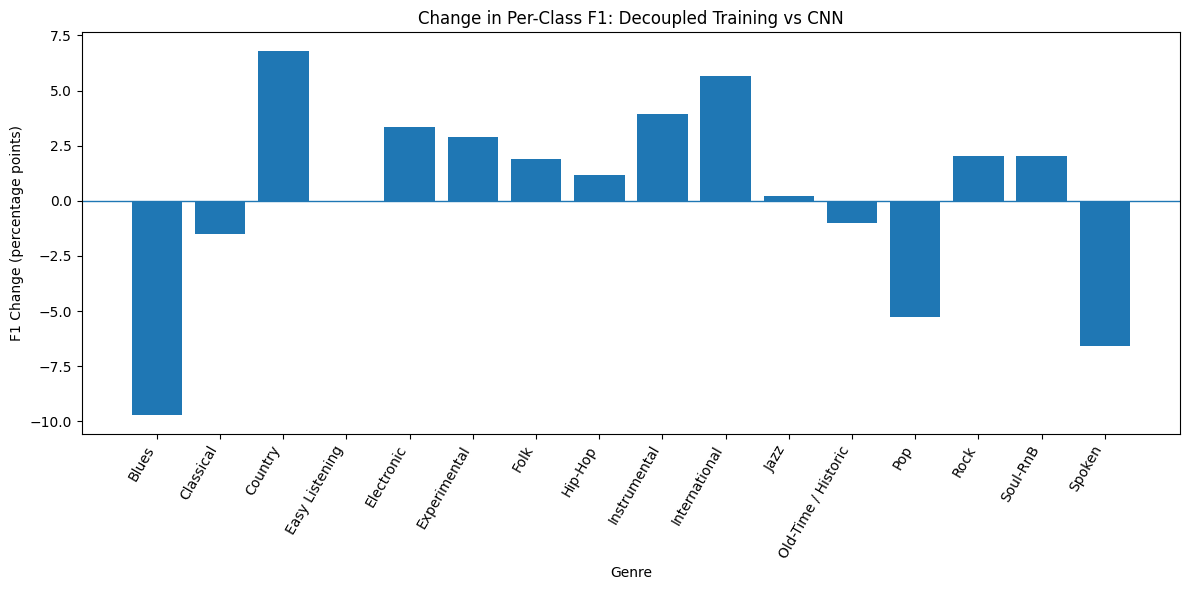

In [14]:
f1_changes = class_comparison["F1 Change (pp)"]

plt.figure(figsize=(12, 6))

plt.bar(
    f1_changes.index,
    f1_changes.values,
)

plt.axhline(0, linewidth=1)

plt.title("Change in Per-Class F1: Decoupled Training vs CNN")
plt.xlabel("Genre")
plt.ylabel("F1 Change (percentage points)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cnn_vs_decoupled_class_f1_change.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
class_comparison[
    [
        "CNN F1",
        "Decoupled F1",
        "F1 Change (pp)",
    ]
].sort_values(
    "F1 Change (pp)",
    ascending=False,
).round(3)

,CNN F1,Decoupled F1,F1 Change (pp)
Country,0.232,0.300,6.812
International,0.425,0.481,5.643
Instrumental,0.338,0.377,3.951
Electronic,0.751,0.784,3.346
Experimental,0.405,0.434,2.901
Rock,0.790,0.810,2.046
Soul-RnB,0.132,0.152,2.031
Folk,0.340,0.359,1.905
Hip-Hop,0.741,0.753,1.187
Jazz,0.457,0.459,0.219


In [16]:
class_comparison[
    [
        "CNN F1",
        "Decoupled F1",
        "F1 Change (pp)",
    ]
].sort_values(
    "F1 Change (pp)",
    ascending=True,
).round(3)

,CNN F1,Decoupled F1,F1 Change (pp)
Blues,0.273,0.175,-9.729
Spoken,0.385,0.319,-6.577
Pop,0.289,0.237,-5.275
Classical,0.716,0.701,-1.492
Old-Time / Historic,0.971,0.962,-0.989
Easy Listening,0.000,0.000,0.000
Jazz,0.457,0.459,0.219
Hip-Hop,0.741,0.753,1.187
Folk,0.340,0.359,1.905
Soul-RnB,0.132,0.152,2.031


In [17]:
recall_comparison = class_comparison[
    [
        "CNN Recall",
        "Decoupled Recall",
    ]
].copy()

recall_comparison.round(3)

,CNN Recall,Decoupled Recall
Blues,0.375,0.625
Classical,0.855,0.871
Country,0.444,0.500
Easy Listening,0.000,0.000
Electronic,0.684,0.718
Experimental,0.418,0.418
Folk,0.368,0.362
Hip-Hop,0.755,0.727
Instrumental,0.368,0.362
International,0.373,0.373


In [18]:
recall_comparison["Recall Change (pp)"] = (
    recall_comparison["Decoupled Recall"]
    - recall_comparison["CNN Recall"]
) * 100

recall_comparison.round(2)

,CNN Recall,Decoupled Recall,Recall Change (pp)
Blues,0.38,0.62,25.00
Classical,0.85,0.87,1.61
Country,0.44,0.50,5.56
Easy Listening,0.00,0.00,0.00
Electronic,0.68,0.72,3.48
Experimental,0.42,0.42,0.00
Folk,0.37,0.36,-0.66
Hip-Hop,0.75,0.73,-2.73
Instrumental,0.37,0.36,-0.57
International,0.37,0.37,0.00


## Observations

The confusion matrices show that Decoupled Training changes the classifier's decision boundaries rather than improving every class uniformly.

Several classes show higher F1 under Decoupled Training, including Country, International, Instrumental, Electronic, Experimental, Rock, Soul-RnB, Folk, and Hip-Hop.

Other classes show lower F1, including Blues, Pop, and Spoken.

The change in Blues illustrates the precision-recall trade-off: recall increases substantially, while precision decreases because the model predicts Blues more frequently.

Similarly, Spoken recall increases, but its F1 decreases because the additional Spoken predictions introduce more false positives.

The overall improvement in balanced accuracy therefore comes from changes in class recall across the dataset, while the smaller Macro-F1 improvement reflects the precision-recall trade-offs across individual classes.

In [19]:
class_comparison.to_csv(
    METRICS_DIR / "cnn_vs_decoupled_class_comparison.csv"
)

print("Saved class-level comparison.")

Saved class-level comparison.
